In [75]:
import numpy as np 
import matplotlib.pyplot as plt


In [76]:
# def rbf(x1,x2,length_scale = 1.0,sigma = 1.0):
#     # square_dist = np.sum((x1[:,np.newaxis,] - x2[np.newaxis,:,])**2,axis=2) 
    
#     return sigma* np.exp(-square_dist/(2*length_scale**2))


# # gaussian Process Regressor class 
# class GaussianProcessRegressor:
#     def __init__(self,kernel=rbf,noise = 1e-6):
#         self.kernel = kernel
#         self.noise = noise
#         self.length_scale = 1.0
#         self.sigma = 1.0
#     def fit(self, X_train,Y_train):
#         self.x = X_train
#         self.y = Y_train
#     def neg_log_likelihood(params):
#         length_scale,sigma = params
        
        



In [77]:
import torch
import torch.nn.functional as F


In [78]:
class ardrbf:
    def __init__(self,sigma =1.0 ,dim = 1):
        self.dim =dim 
        self.length_scales =  torch.ones(dim,requires_grad=True)
        self.sigma = torch.tensor(sigma,requires_grad=True)
    def __call__(self,x1,x2):
        """
        ARD RBF kernel with learnable length scales and sigma.
        Args:
            x1 (array_like): shape (n1,d)
            x2 (array_like): shape (n2,d)
        return: 
            arraylike: shape (n1,n2)
        """
        square_dist = torch.sum(((x1[:,None,:] - x2[None,:,:])**2)*(self.length_scales**-2),dim = 2)
        return self.sigma*torch.exp(-0.5*square_dist)
    def parameters(self):
        return [self.sigma,self.length_scales]
    
class gaussianProcessRegressor:
    def __init__(self,kernel, noise = 1e-6):
        self.kernel = kernel
        self.noise = noise 
    def fit(self,X_train,Y_train):
        self.x =X_train
        self.y = Y_train
        self.K = self.kernel(self.x,self.x) + self.noise*torch.eye(self.x.shape[0])
        self.L = torch.linalg.cholesky(self.K)
        
    def predict(self,x_test):
        """ currently expecting a batch-of test"""
        k_ = self.kernel(self.x,x_test) # shape (n,n*)
        k__ = self.kernel(x_test,x_test) # shape (n*,n*)  thought we only need the diag elements 
        alpha = torch.cholesky_solve(self.y,self.L)
        mu = k_.T @ alpha
        # mue = k_.T@self.Kinv@self.y  # (n,n*)T@(n,n)@(n,)
        v = torch.cholesky_solve(k_,self.L)
        
        sigma = k__ - k_.T@v
        print(sigma)
        return mu.squeeze(),sigma.diag().squeeze()
    
        
        
        
        
        
        
        

In [79]:
#Example 
torch.manual_seed(42)
x_train = torch.rand(10,1)*10 - 5
y_train = torch.sin(x_train) + 0.5 * torch.randn(x_train.size())
X_test = torch.linspace(-6, 6, 100).unsqueeze(1)
kernel = ardrbf()
GP = gaussianProcessRegressor(kernel)
GP.fit(x_train,y_train)

In [80]:

optimizer = torch.optim.Adam(kernel.parameters(),lr=1e-3)
for i in range(50):
    optimizer.zero_grad()
    # compute criterion
    Ky = kernel(x_train,x_train) + GP.noise*torch.eye(x_train.shape[0])
    L = torch.cholesky(Ky)
    loss = 0.5*(GP.y.T@torch.cholesky_solve(GP.y,Ky)) + 0.5*torch.logdet(Ky) + 0.5*GP.x.shape[0]*torch.log(torch.tensor(2*torch.pi))
    loss.backward()
    optimizer.step()
    if i%10 == 0 or i == 50 - 1:
       print(f"Iteration {i}, Loss: {loss.item():.4f}, Length Scales: {kernel.length_scales.detach().numpy()}, sigma: {kernel.sigma}")

        

Iteration 0, Loss: 3.0847, Length Scales: [1.001], sigma: 1.0010000467300415
Iteration 10, Loss: 2.9049, Length Scales: [1.0109957], sigma: 1.0109859704971313
Iteration 20, Loss: 2.7291, Length Scales: [1.0209752], sigma: 1.020909309387207
Iteration 30, Loss: 2.5567, Length Scales: [1.0309273], sigma: 1.0307289361953735
Iteration 40, Loss: 2.3886, Length Scales: [1.0408477], sigma: 1.040419101715088
Iteration 49, Loss: 2.2396, Length Scales: [1.0497487], sigma: 1.0490193367004395


tensor([[1.0380e+00, 1.0280e+00, 1.0036e+00,  ..., 2.1928e-04, 2.4272e-04,
         2.6044e-04],
        [1.0280e+00, 1.0310e+00, 1.0193e+00,  ..., 2.7654e-04, 3.0611e-04,
         3.2845e-04],
        [1.0036e+00, 1.0193e+00, 1.0204e+00,  ..., 3.4320e-04, 3.7989e-04,
         4.0763e-04],
        ...,
        [2.1928e-04, 2.7654e-04, 3.4319e-04,  ..., 1.2345e-01, 1.5594e-01,
         1.8682e-01],
        [2.4272e-04, 3.0612e-04, 3.7989e-04,  ..., 1.5594e-01, 1.9585e-01,
         2.3425e-01],
        [2.6044e-04, 3.2846e-04, 4.0762e-04,  ..., 1.8682e-01, 2.3426e-01,
         2.8050e-01]], grad_fn=<SubBackward0>)
tensor([ 1.0380e+00,  1.0310e+00,  1.0204e+00,  1.0047e+00,  9.8233e-01,
         9.5146e-01,  9.1029e-01,  8.5726e-01,  7.9138e-01,  7.1259e-01,
         6.2207e-01,  5.2241e-01,  4.1760e-01,  3.1279e-01,  2.1370e-01,
         1.2591e-01,  5.3938e-02,  5.4288e-04, -3.3829e-02, -5.1097e-02,
        -5.5136e-02, -5.0956e-02, -4.3647e-02, -3.7367e-02, -3.4623e-02,
        -3.6042

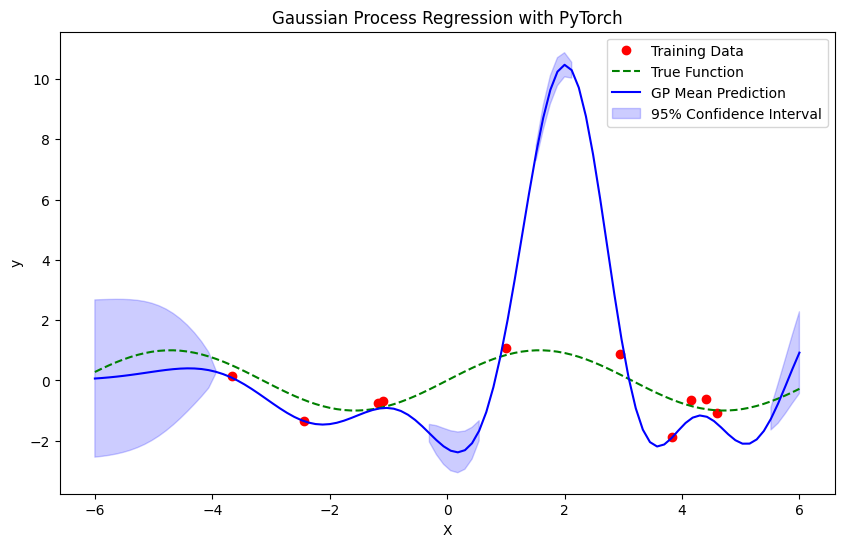

In [81]:
mu,var = GP.predict(X_test)
print(var)
# Plot the results
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(x_train.numpy(), y_train.numpy(), "ro", label="Training Data")
plt.plot(X_test.numpy(), torch.sin(X_test).numpy(), "g--", label="True Function")
plt.plot(X_test.numpy(), mu.detach().numpy(), "b-", label="GP Mean Prediction")
plt.fill_between(
    X_test.squeeze().numpy(),
    mu.detach().numpy() - 2.56 * torch.sqrt(var).detach().numpy(),
    mu.detach().numpy() + 2.56 * torch.sqrt(var).detach().numpy(),
    color="blue",
    alpha=0.2,
    label="95% Confidence Interval",
)
plt.legend()
plt.title("Gaussian Process Regression with PyTorch")
plt.xlabel("X")
plt.ylabel("y")
plt.show()


